Bibs

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt
import sqlite3

Data inlezen en kolommen selecteren

In [12]:
from datetime import datetime

sales_conn = sqlite3.connect('go_sales_train.sqlite')

df_return_item = pd.read_sql_query("select RETURN_REASON_CODE, RETURN_DATE, ORDER_DETAIL_CODE from returned_item", sales_conn)
df_order_details = pd.read_sql_query("select ORDER_DETAIL_CODE, QUANTITY, UNIT_PRICE, UNIT_SALE_PRICE, PRODUCT_NUMBER, ORDER_NUMBER from order_details", sales_conn)
df_product = pd.read_sql_query("select PRODUCT_TYPE_CODE, INTRODUCTION_DATE, PRODUCTION_COST, MARGIN, PRODUCT_NUMBER from product", sales_conn)
df_order_header = pd.read_sql_query("select ORDER_NUMBER, ORDER_DATE, ORDER_METHOD_CODE from order_header", sales_conn)

df = pd.merge(df_return_item, df_order_details, on="ORDER_DETAIL_CODE", how="right")

df = pd.merge(df, df_product, on="PRODUCT_NUMBER", how="inner")
df = pd.merge(df, df_order_header, on="ORDER_NUMBER", how="inner")





df['INTRODUCTION_DATE'] = pd.to_datetime(df['INTRODUCTION_DATE'])
df['RETURN_DATE'] = pd.to_datetime(df['RETURN_DATE'])
df['ORDER_DATE'] = pd.to_datetime(df['ORDER_DATE'])

huidig_jaar = datetime.now().year
df['YearsSinceIntroduction'] = huidig_jaar - df['INTRODUCTION_DATE'].dt.year
df['Time_Between_Order_Return'] = (df['RETURN_DATE'] - df['ORDER_DATE']).dt.days

df.drop(['INTRODUCTION_DATE', 'PRODUCT_NUMBER', 'RETURN_DATE', 'ORDER_DATE'], axis=1, inplace=True)

df["RETURN_REASON_CODE"] = df["RETURN_REASON_CODE"].fillna(0)
df["Time_Between_Order_Return"] = df["Time_Between_Order_Return"].fillna(0)

# print(df)
# df.dtypes 
unique_reasons = df['RETURN_REASON_CODE'].unique()
print("Unieke RETURN_REASON_CODE waarden:", unique_reasons)

Unieke RETURN_REASON_CODE waarden: [0. 3. 2. 4. 5. 1.]


snijden

In [13]:
X = df.drop('RETURN_REASON_CODE', axis = 1)
y = df.loc[:, ['RETURN_REASON_CODE']]
X

,ORDER_DETAIL_CODE,QUANTITY,UNIT_PRICE,UNIT_SALE_PRICE,ORDER_NUMBER,PRODUCT_TYPE_CODE,PRODUCTION_COST,MARGIN,ORDER_METHOD_CODE,YearsSinceIntroduction,Time_Between_Order_Return
0,47737,84,6.59,6.59,1638,1,4.0,0.33,7,30,0.0
1,47738,126,6.59,6.59,1159,1,4.0,0.33,7,30,0.0
2,47739,122,6.59,6.03,1171,1,4.0,0.33,3,30,0.0
3,47740,122,6.59,6.59,1154,1,4.0,0.33,4,30,0.0
4,47741,272,6.59,5.26,1205,1,4.0,0.33,4,30,0.0
...,...,...,...,...,...,...,...,...,...,...,...
37752,115289,70,9.00,9.00,7631,21,6.0,0.33,5,21,0.0
37753,115290,44,12.00,9.00,7627,21,6.0,0.50,5,21,0.0
37754,115291,8,200.00,140.00,7630,21,80.0,0.60,2,22,0.0
37755,115292,24,10.00,10.00,7631,21,5.0,0.50,5,22,0.0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state = 42
)

In [15]:
list(X.columns)

['ORDER_DETAIL_CODE',
 'QUANTITY',
 'UNIT_PRICE',
 'UNIT_SALE_PRICE',
 'ORDER_NUMBER',
 'PRODUCT_TYPE_CODE',
 'PRODUCTION_COST',
 'MARGIN',
 'ORDER_METHOD_CODE',
 'YearsSinceIntroduction',
 'Time_Between_Order_Return']

Decision Tree

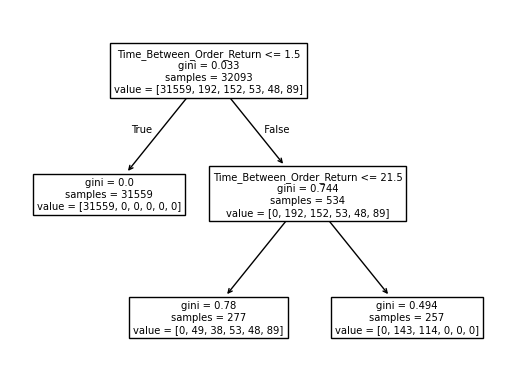

In [16]:
dtree = DecisionTreeClassifier(max_depth = 2)
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()

In [17]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_RETURN_REASON_CODE'})
model_results_frame = pd.concat([y_test.reset_index()['RETURN_REASON_CODE'], predicted_df], axis = 1)
model_results_frame


,RETURN_REASON_CODE,Predicted_RETURN_REASON_CODE
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
5659,0.0,0.0
5660,0.0,0.0
5661,0.0,0.0
5662,0.0,0.0


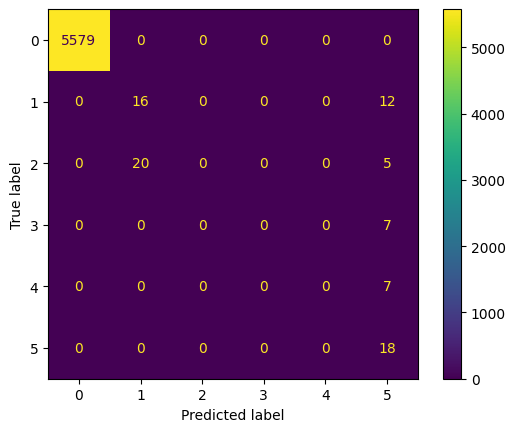

In [18]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['RETURN_REASON_CODE'], model_results_frame['Predicted_RETURN_REASON_CODE'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0,1,2,3,4,5])

cm_display.plot()
plt.show()

In [19]:
metrics.accuracy_score(model_results_frame['RETURN_REASON_CODE'], model_results_frame['Predicted_RETURN_REASON_CODE'])


0.9909957627118644

zonder max depth

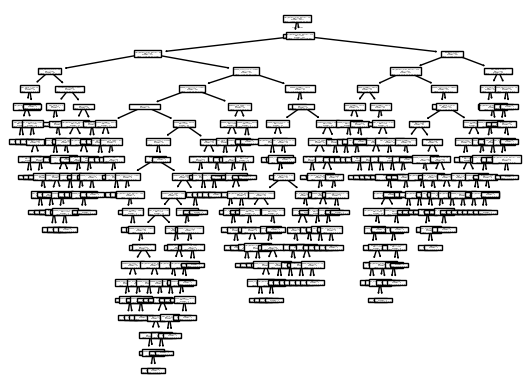

In [20]:
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()

In [21]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_RETURN_REASON_CODE'})
model_results_frame = pd.concat([y_test.reset_index()['RETURN_REASON_CODE'], predicted_df], axis = 1)
model_results_frame

,RETURN_REASON_CODE,Predicted_RETURN_REASON_CODE
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
5659,0.0,0.0
5660,0.0,0.0
5661,0.0,0.0
5662,0.0,0.0


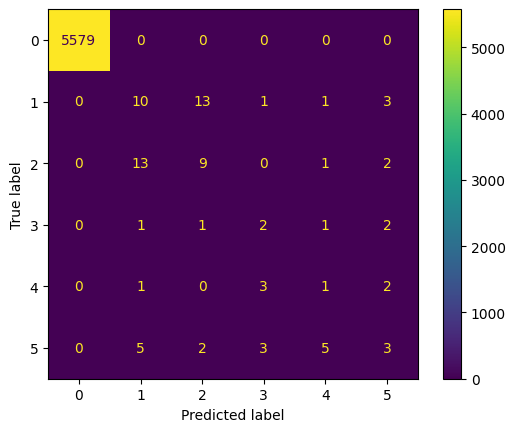

In [22]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['RETURN_REASON_CODE'], model_results_frame['Predicted_RETURN_REASON_CODE'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0,1,2,3,4,5])

cm_display.plot()
plt.show()

In [23]:
metrics.accuracy_score(model_results_frame['RETURN_REASON_CODE'], model_results_frame['Predicted_RETURN_REASON_CODE'])


0.989406779661017